In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

## Build NetworkX graph from CSV data

In [2]:
df = pd.read_csv('../data/network_data.csv')

G = nx.Graph()

# Add nodes with position and road info
for _, row in df.iterrows():
    G.add_node(
        int(row['id']),
        road=row['road'],
        model_type=row['model_type'].strip(),
        pos=(row['lon'], row['lat']),
    )

# Add edges between consecutive components on each road
for road in df['road'].unique():
    road_ids = df[df['road'] == road]['id'].tolist()
    for i in range(len(road_ids) - 1):
        length = max(float(df[df['id'] == road_ids[i]].iloc[0]['length']), 1)
        G.add_edge(int(road_ids[i]), int(road_ids[i+1]), road=road, weight=length)

pos = nx.get_node_attributes(G, 'pos')
print(f'Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}, Connected: {nx.is_connected(G)}')

Nodes: 4070, Edges: 4074, Connected: True


## Full Network – Geographic Layout

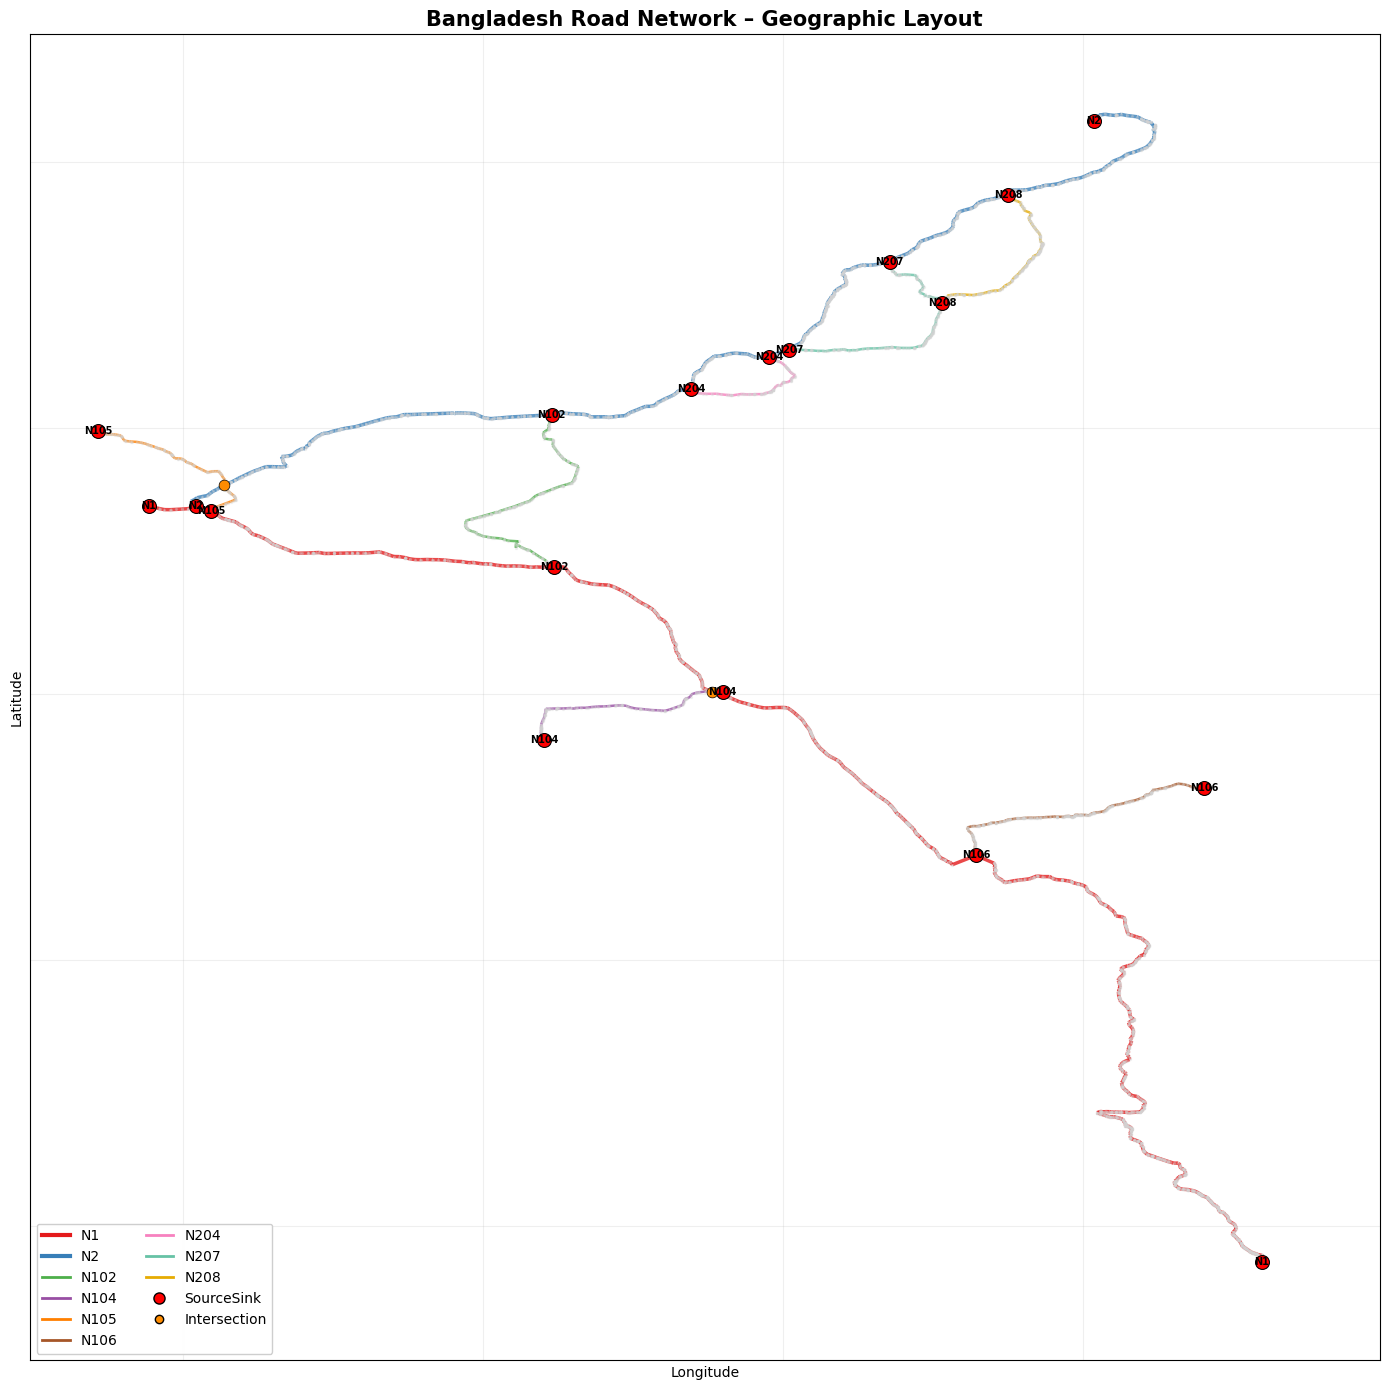

In [3]:
road_colors = {
    'N1': '#e41a1c', 'N2': '#377eb8', 'N102': '#4daf4a', 'N104': '#984ea3',
    'N105': '#ff7f00', 'N106': '#a65628', 'N204': '#f781bf', 'N207': '#66c2a5',
    'N208': '#e6ab02'
}

# Classify nodes
model_types = nx.get_node_attributes(G, 'model_type')
ss_nodes = [n for n, t in model_types.items() if t == 'sourcesink']
int_nodes = [n for n, t in model_types.items() if t == 'intersection']
other_nodes = [n for n, t in model_types.items() if t not in ('sourcesink', 'intersection')]

# Group edges by road
road_edges = {r: [] for r in road_colors}
for u, v, d in G.edges(data=True):
    r = d.get('road', 'N1')
    if r in road_edges:
        road_edges[r].append((u, v))

fig, ax = plt.subplots(figsize=(14, 14))

# Draw edges per road
for road in road_colors:
    edges = road_edges.get(road, [])
    width = 2.5 if road in ('N1', 'N2') else 1.8
    nx.draw_networkx_edges(G, pos, edgelist=edges, ax=ax,
                           edge_color=road_colors[road], width=width, alpha=0.8)

# Draw nodes
nx.draw_networkx_nodes(G, pos, nodelist=other_nodes, ax=ax,
                       node_color='lightgray', node_size=2, alpha=0.3)
nx.draw_networkx_nodes(G, pos, nodelist=int_nodes, ax=ax,
                       node_color='darkorange', node_size=60, edgecolors='black', linewidths=0.5)
nx.draw_networkx_nodes(G, pos, nodelist=ss_nodes, ax=ax,
                       node_color='red', node_size=100, edgecolors='black', linewidths=0.8)

# Label SourceSinks
road_attrs = nx.get_node_attributes(G, 'road')
ss_labels = {n: road_attrs.get(n, '') for n in ss_nodes}
nx.draw_networkx_labels(G, pos, labels=ss_labels, font_size=7, font_weight='bold', ax=ax)

# Legend
for road, color in road_colors.items():
    lw = 3 if road in ('N1', 'N2') else 2
    ax.plot([], [], color=color, linewidth=lw, label=road)
ax.plot([], [], 'o', color='red', markersize=8, markeredgecolor='black', label='SourceSink')
ax.plot([], [], 'o', color='darkorange', markersize=6, markeredgecolor='black', label='Intersection')
ax.legend(loc='lower left', fontsize=10, ncol=2, framealpha=0.95)
ax.set_title('Bangladesh Road Network – Geographic Layout', fontsize=15, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('../img/network_geographic.png', dpi=150, bbox_inches='tight')
plt.show()

## Simplified Network – Key Nodes Only

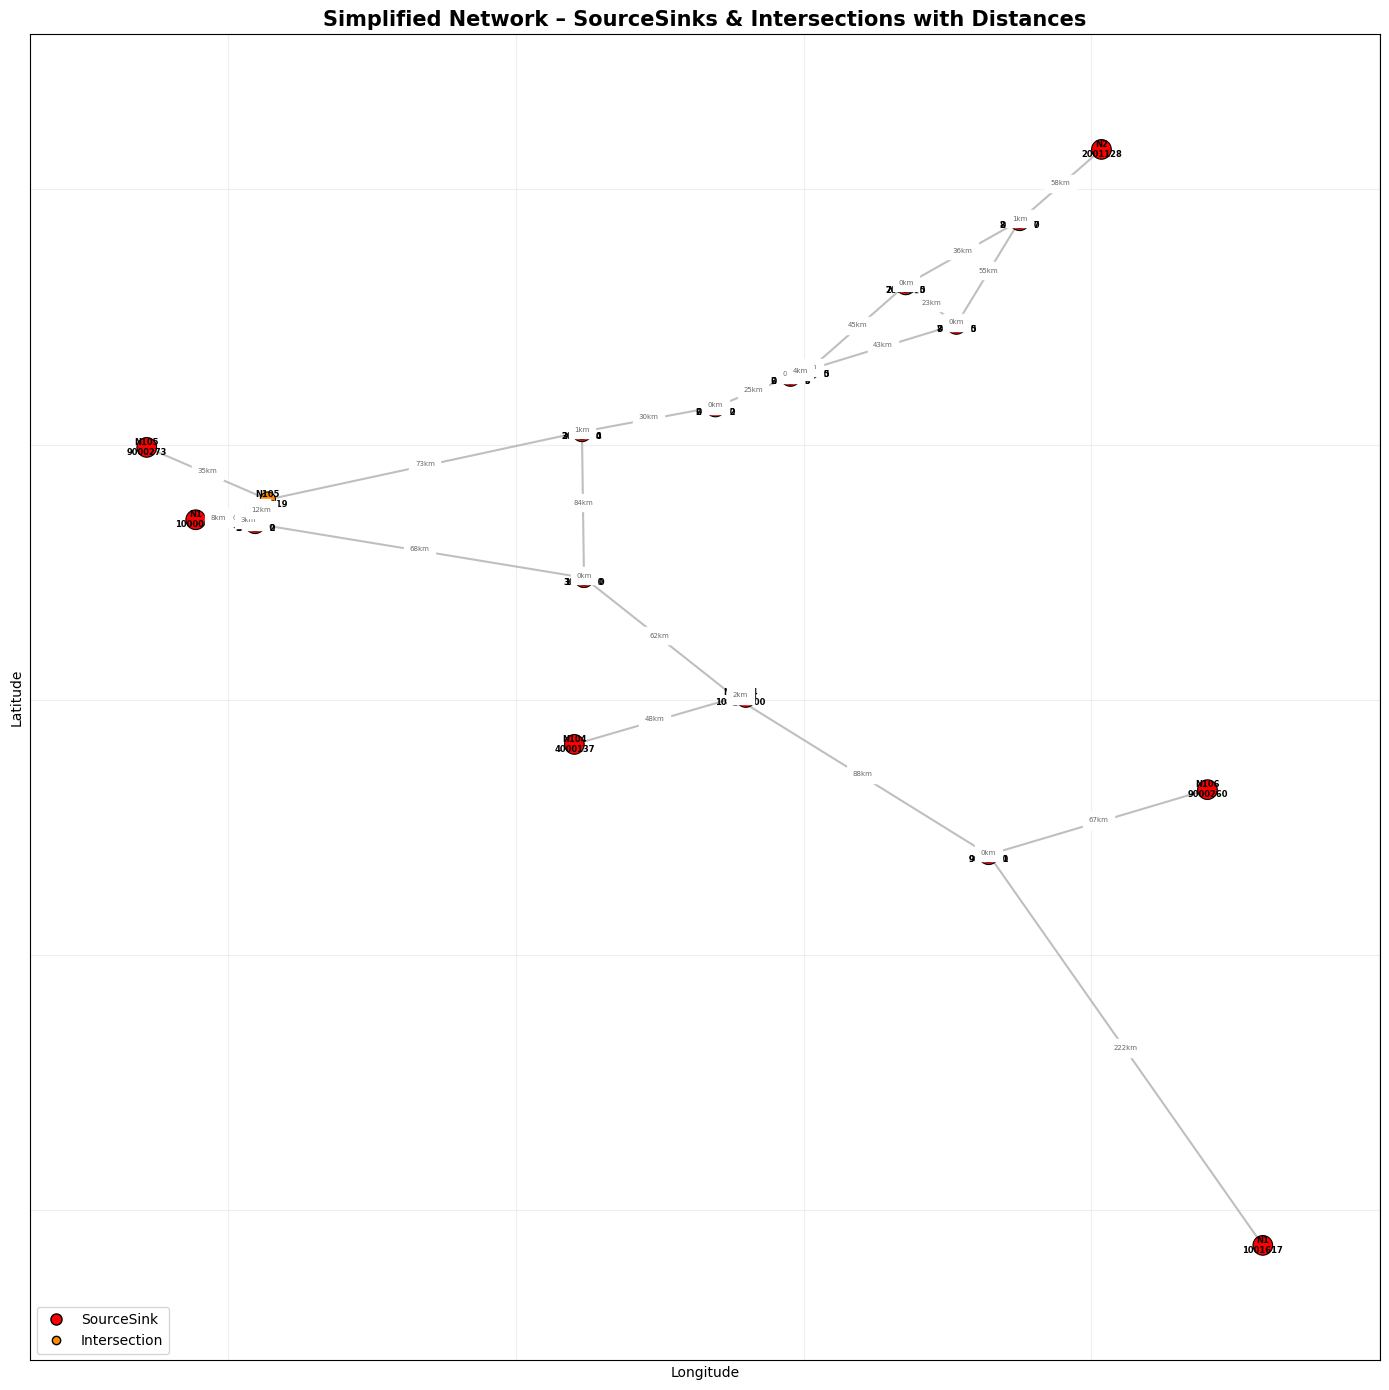

In [4]:
# Build simplified graph with only SourceSinks and Intersections
key_nodes = ss_nodes + int_nodes
key_graph = nx.Graph()

for n in key_nodes:
    key_graph.add_node(n, **{k: G.nodes[n][k] for k in G.nodes[n]})

# Connect key nodes that are direct neighbors (no other key node between them)
for i, n1 in enumerate(key_nodes):
    for n2 in key_nodes[i+1:]:
        try:
            path = nx.shortest_path(G, n1, n2, weight='weight')
            intermediates = [p for p in path[1:-1] if p in key_nodes]
            if not intermediates:
                dist = nx.shortest_path_length(G, n1, n2, weight='weight')
                key_graph.add_edge(n1, n2, weight=dist/1000)
        except nx.NetworkXNoPath:
            pass

key_pos = {n: pos[n] for n in key_nodes if n in pos}
key_colors = ['red' if n in ss_nodes else 'darkorange' for n in key_graph.nodes()]
key_sizes = [200 if n in ss_nodes else 120 for n in key_graph.nodes()]
key_labels = {n: f"{road_attrs.get(n, '')}\n{n}" for n in key_graph.nodes()}

fig, ax = plt.subplots(figsize=(14, 14))

# Draw edges with distance annotations
nx.draw_networkx_edges(key_graph, key_pos, ax=ax, alpha=0.5, width=1.5, edge_color='gray')
nx.draw_networkx_nodes(key_graph, key_pos, ax=ax, node_color=key_colors,
                       node_size=key_sizes, edgecolors='black', linewidths=0.8)
nx.draw_networkx_labels(key_graph, key_pos, labels=key_labels,
                        font_size=6, font_weight='bold', ax=ax)

# Annotate edge distances manually
for u, v, d in key_graph.edges(data=True):
    x = (key_pos[u][0] + key_pos[v][0]) / 2
    y = (key_pos[u][1] + key_pos[v][1]) / 2
    ax.annotate(f'{d["weight"]:.0f}km', (x, y), fontsize=5, ha='center',
                color='dimgray', backgroundcolor='white')

ax.plot([], [], 'o', color='red', markersize=8, markeredgecolor='black', label='SourceSink')
ax.plot([], [], 'o', color='darkorange', markersize=6, markeredgecolor='black', label='Intersection')
ax.legend(loc='lower left', fontsize=10)
ax.set_title('Simplified Network – SourceSinks & Intersections with Distances',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('../img/network_simplified.png', dpi=150, bbox_inches='tight')
plt.show()

## Network Statistics

In [5]:
print(f'Total nodes: {G.number_of_nodes()}')
print(f'Total edges: {G.number_of_edges()}')
print(f'Connected: {nx.is_connected(G)}')
print(f'SourceSinks: {len(ss_nodes)}')
print(f'Intersections: {len(int_nodes)}')
print()
print('Per-road component counts:')
for road in road_colors:
    count = len([n for n, d in G.nodes(data=True) if d.get('road') == road])
    edges = len(road_edges.get(road, []))
    total_km = sum(d.get('weight', 0) for u, v, d in G.edges(data=True)
                   if d.get('road') == road) / 1000
    print(f'  {road}: {count} nodes, {edges} edges, ~{total_km:.0f} km')

Total nodes: 4070
Total edges: 4074
Connected: True
SourceSinks: 18
Intersections: 13

Per-road component counts:
  N1: 1614 nodes, 1618 edges, ~451 km
  N2: 1123 nodes, 1129 edges, ~283 km
  N102: 263 nodes, 262 edges, ~85 km
  N104: 139 nodes, 138 edges, ~50 km
  N105: 131 nodes, 130 edges, ~47 km
  N106: 262 nodes, 261 edges, ~67 km
  N204: 113 nodes, 112 edges, ~34 km
  N207: 202 nodes, 202 edges, ~66 km
  N208: 223 nodes, 222 edges, ~56 km
